## 3D Visualization of House Price Prediction Regression Model

In [ ]:
!pip install numpy matplotlib plotly scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

## 1. Sample house price dataset

In [3]:
# Features
area = np.array([800, 1000, 1200, 1500, 1800, 2000])
bedrooms = np.array([1, 2, 2, 3, 3, 4])
# Target
price = np.array([50, 65, 80, 110, 140, 170])  # e.g. in lakhs


## 2. Model

In [4]:
X = np.column_stack((area, bedrooms))
y = price

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 3. Create regression surface

In [5]:
# Create grid for surface
area_grid, bedroom_grid = np.meshgrid(
    np.linspace(area.min(), area.max(), 20),
    np.linspace(bedrooms.min(), bedrooms.max(), 20)
)

X_grid = np.column_stack((
    area_grid.ravel(),
    bedroom_grid.ravel()
))

price_pred = model.predict(X_grid)
price_grid = price_pred.reshape(area_grid.shape)

## 4. Plot 3D regression graph

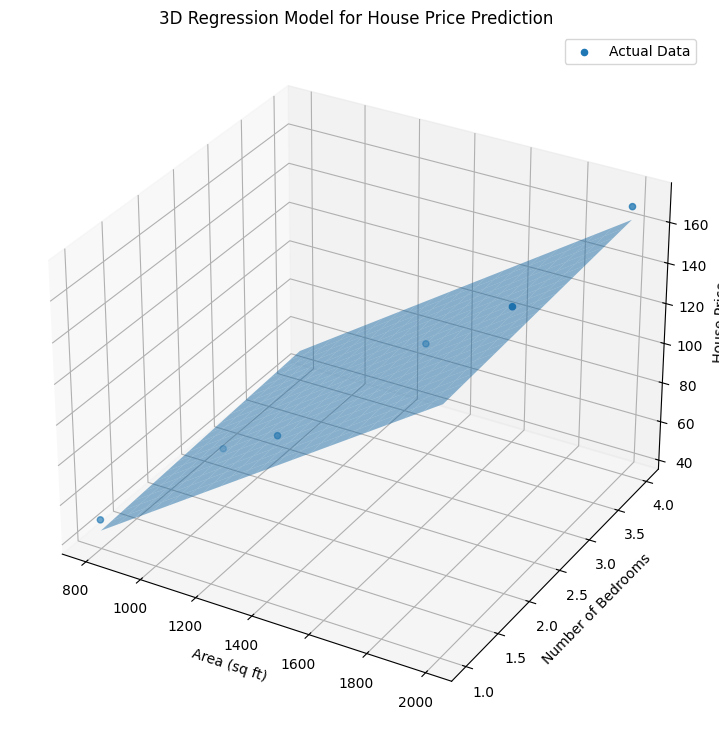

In [12]:
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(area, bedrooms, price, marker='o', label="Actual Data")

# Regression surface
ax.plot_surface(area_grid, bedroom_grid, price_grid, alpha=0.5)

# Labels
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Number of Bedrooms")
ax.set_zlabel("House Price")

ax.set_title("3D Regression Model for House Price Prediction")
ax.legend()

plt.show()

## 5. Using Plotly

In [10]:
import plotly.graph_objects as go
fig = go.Figure()

# Actual data points
fig.add_trace(go.Scatter3d(
    x=area,
    y=bedrooms,
    z=price,
    mode='markers',
    marker=dict(size=6),
    name='Actual Data'
))

# Regression surface
fig.add_trace(go.Surface(
    x=area_grid,
    y=bedroom_grid,
    z=price_grid,
    opacity=0.7,
    name='Regression Surface'
))

# Labels and title
fig.update_layout(
    title="Interactive 3D Regression Model for House Price Prediction",
    scene=dict(
        xaxis_title="Area (sq ft)",
        yaxis_title="Number of Bedrooms",
        zaxis_title="House Price"
    )
)

fig.show()
